## Ejercicio para la toma de decisiones con base en datos 

In [1]:
# Importaciones para dataframe
import numpy as np
import pandas as pd

#Importaciones para manejo de df
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Set de semillas para reproducibilidad
np.random.seed(42)

# Número de registros
n = 500

# Generación del dataset
df = pd.DataFrame({
    "cliente_id": range(1, n+1),
    "edad": np.random.randint(18, 65, size=n),
    "genero": np.random.choice(["Hombre", "Mujer"], size=n),
    "ciudad": np.random.choice(
        ["CDMX", "Monterrey", "Guadalajara", "Puebla", "Tijuana"],
        size=n
    ),
    "ingreso_mensual": np.random.normal(25000, 9000, size=n).astype(int),
    "visitas_mes": np.random.poisson(4, size=n),
    "compra_mes": np.random.binomial(1, 0.6, size=n),  # 0 = no compra, 1 = compra
    "monto_compra": np.abs(np.random.normal(600, 250, size=n))  # monto si compra
})

# Si el cliente no compró, monto de compra es cero
df.loc[df["compra_mes"] == 0, "monto_compra"] = 0

In [3]:
# Indicamos número de filas y columnas
df.shape

(500, 8)

In [4]:
# Mostramos las primeras cinco filas del dataset
df.head()

,cliente_id,edad,genero,ciudad,ingreso_mensual,visitas_mes,compra_mes,monto_compra
0,1,56,Hombre,CDMX,32366,7,0,0.000000
1,2,46,Hombre,Guadalajara,26204,7,1,321.488387
2,3,32,Hombre,Tijuana,29019,2,0,0.000000
3,4,60,Hombre,CDMX,23080,6,1,653.184944
4,5,25,Hombre,Monterrey,35161,6,1,795.718434


In [5]:
# Mostramos las últimas cinco filas del dataset
df.tail()

,cliente_id,edad,genero,ciudad,ingreso_mensual,visitas_mes,compra_mes,monto_compra
495,496,37,Hombre,Tijuana,22850,0,1,601.057465
496,497,41,Hombre,Monterrey,25784,2,1,754.721575
497,498,29,Mujer,Monterrey,31372,4,1,1009.589933
498,499,52,Hombre,CDMX,17367,4,1,695.327403
499,500,50,Hombre,Monterrey,10590,3,1,677.913214


In [6]:
# Mostramos 5 registros aleatorios
df.sample(5)

,cliente_id,edad,genero,ciudad,ingreso_mensual,visitas_mes,compra_mes,monto_compra
361,362,49,Hombre,Monterrey,19591,5,1,748.141818
104,105,25,Hombre,Monterrey,18794,10,0,0.000000
294,295,19,Mujer,Tijuana,28263,1,1,512.640168
82,83,62,Mujer,Guadalajara,-6327,2,1,724.218398
319,320,44,Hombre,CDMX,19143,5,0,0.000000


In [7]:
# Estructura del DF
# Mostramos el tipo de dato de cada columna (int, float, object, datetime, etc.).
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   cliente_id       500 non-null    int64  
 1   edad             500 non-null    int32  
 2   genero           500 non-null    str    
 3   ciudad           500 non-null    str    
 4   ingreso_mensual  500 non-null    int64  
 5   visitas_mes      500 non-null    int32  
 6   compra_mes       500 non-null    int32  
 7   monto_compra     500 non-null    float64
dtypes: float64(1), int32(3), int64(2), str(2)
memory usage: 25.5 KB


In [8]:
# Estadísticas descriptivas
# Generamos estadísticas de columnas numéricas (media, mediana, percentiles…).
df.describe()

,cliente_id,edad,ingreso_mensual,visitas_mes,compra_mes,monto_compra
count,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000
mean,250.500000,41.278000,25032.064000,3.910000,0.63600,377.916968
std,144.481833,13.389072,8701.648773,2.035236,0.48163,346.006359
min,1.000000,18.000000,-6327.000000,0.000000,0.00000,0.000000
25%,125.750000,30.000000,18803.000000,3.000000,0.00000,0.000000
50%,250.500000,42.000000,25427.000000,4.000000,1.00000,406.001693
75%,375.250000,52.000000,30807.750000,5.000000,1.00000,660.758602
max,500.000000,64.000000,51685.000000,10.000000,1.00000,1410.773242


In [9]:
# Detectamos si hay nulos
df.isna().sum()

cliente_id         0
edad               0
genero             0
ciudad             0
ingreso_mensual    0
visitas_mes        0
compra_mes         0
monto_compra       0
dtype: int64

In [10]:
#resumen automático
def resumen_eda(df):
    print("### Dimensiones ###")
    print(df.shape)
    print("\n### Tipos de Datos ###")
    print(df.dtypes)
    print("\n### Nulos ###")
    print(df.isnull().sum())
    print("\n### Estadísticas ###")
    print(df.describe())

resumen_eda(df)

### Dimensiones ###
(500, 8)

### Tipos de Datos ###
cliente_id           int64
edad                 int32
genero                 str
ciudad                 str
ingreso_mensual      int64
visitas_mes          int32
compra_mes           int32
monto_compra       float64
dtype: object

### Nulos ###
cliente_id         0
edad               0
genero             0
ciudad             0
ingreso_mensual    0
visitas_mes        0
compra_mes         0
monto_compra       0
dtype: int64

### Estadísticas ###
       cliente_id        edad  ingreso_mensual  visitas_mes  compra_mes  \
count  500.000000  500.000000       500.000000   500.000000   500.00000   
mean   250.500000   41.278000     25032.064000     3.910000     0.63600   
std    144.481833   13.389072      8701.648773     2.035236     0.48163   
min      1.000000   18.000000     -6327.000000     0.000000     0.00000   
25%    125.750000   30.000000     18803.000000     3.000000     0.00000   
50%    250.500000   42.000000     25427.000000   

## Distribución de variables numéricas

In [11]:
# Mostramos la cantidad veces que aparece cada categoría
df['ciudad'].value_counts()

ciudad
CDMX           109
Guadalajara    106
Monterrey       99
Tijuana         97
Puebla          89
Name: count, dtype: int64

In [12]:
df["genero"].value_counts()

genero
Hombre    271
Mujer     229
Name: count, dtype: int64

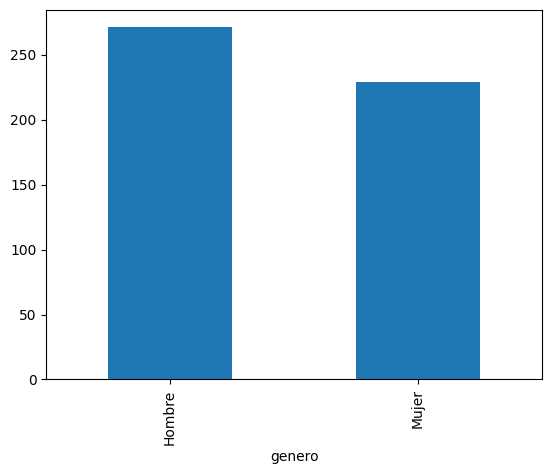

In [13]:
df["genero"].value_counts().plot(kind="bar")
plt.show()

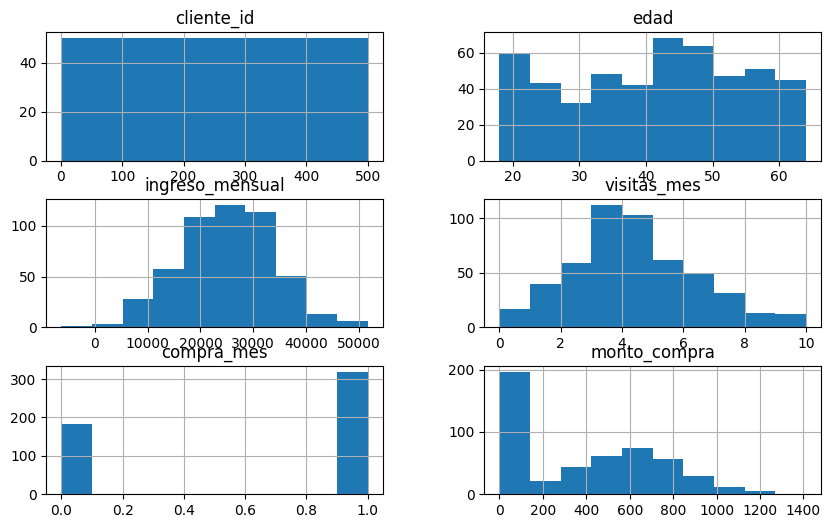

In [14]:
#Distribución de variables numéricas
# Generamos Histogramas automáticos para todas las columnas numéricas

df.hist(figsize=(10,6))
plt.show()

In [15]:
# Análisis cruzado
# Promedio de ingresos por ciudad

df.groupby("ciudad")["ingreso_mensual"].mean().sort_values()


ciudad
CDMX           23709.018349
Puebla         24936.269663
Guadalajara    25122.216981
Monterrey      25483.989899
Tijuana        26046.917526
Name: ingreso_mensual, dtype: float64

In [16]:
# Monto promedio gastado por mes
df[df["compra_mes"] == 1]["monto_compra"].mean()

np.float64(594.2090685181963)

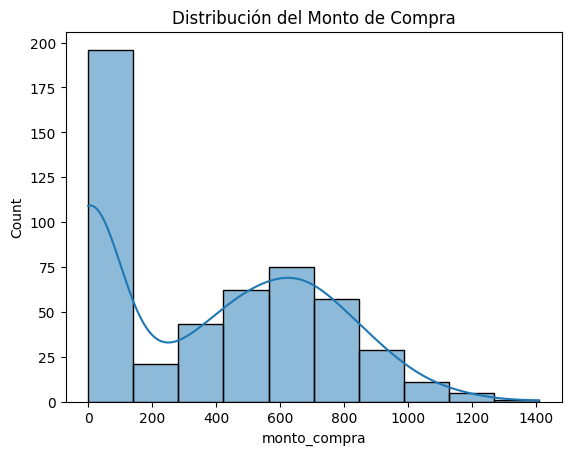

In [17]:
# Distribución del monto de compra
sns.histplot(df["monto_compra"], kde=True)
plt.title("Distribución del Monto de Compra")
plt.show()

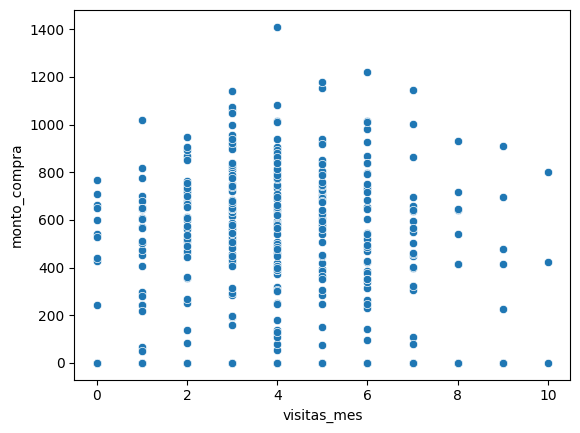

In [18]:
# Relación entre visitas y compras
# Visitar más se relaciona con gastar más?
sns.scatterplot(x="visitas_mes", y="monto_compra", data=df)
plt.show()

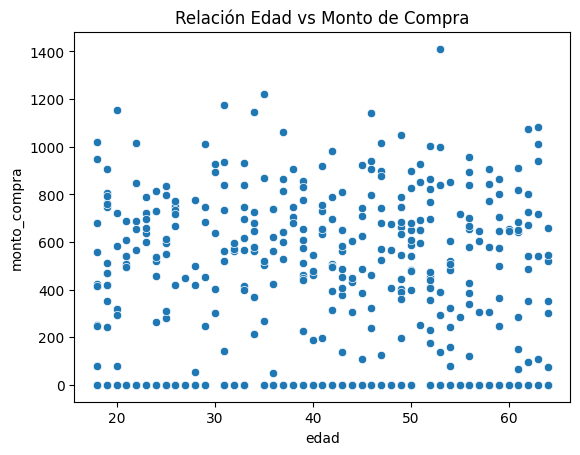

In [19]:
sns.scatterplot(x="edad", y="monto_compra", data=df)
plt.title("Relación Edad vs Monto de Compra")
plt.show()

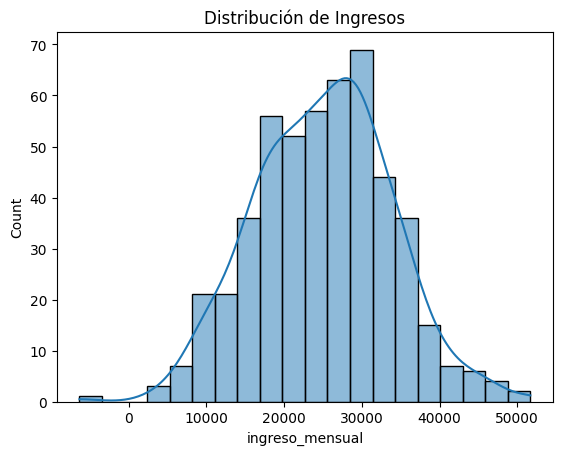

In [20]:
# Graficamos la forma de la distribución (sesgada, normal, picos…).

sns.histplot(df['ingreso_mensual'], kde=True)
plt.title("Distribución de Ingresos")
plt.show()

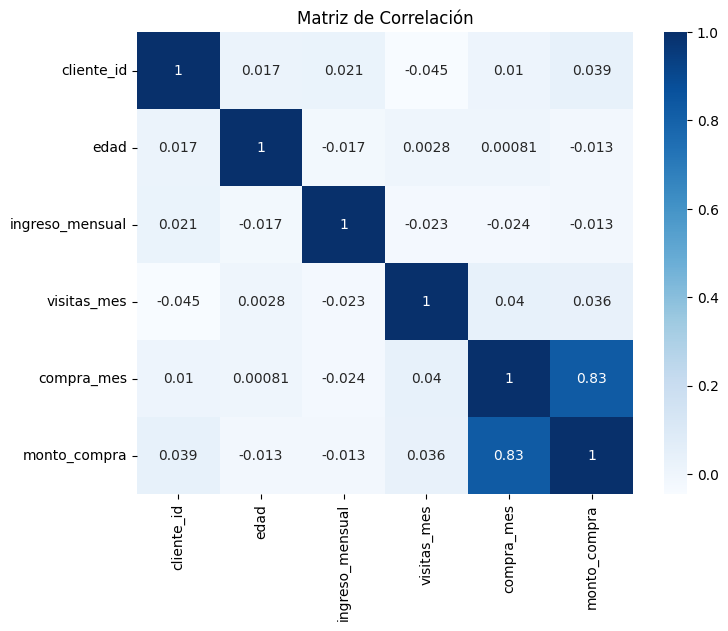

In [21]:
#Matriz de correlación

#Nos quedamos solo con variables numéricas
numeric_df = df.select_dtypes(include=[np.number])

corr = numeric_df.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='Blues')
plt.title("Matriz de Correlación")
plt.show()


In [22]:
df.to_csv("clientes_venta.csv", index=False)

Preguntas de caso:

¿Qué factores predicen mejor que un cliente realice una compra?
¿Hay ciudades con mejor rendimiento comercial?
¿Qué insights se detectan de la relación edad–gasto?
¿Qué decisión propondrías al área comercial basada en los datos?

Ejercicio:

Identificación de un hallazgo / generar Insights
Interpretación de hallazgo
Integrara una recomendación asociada
¿Qué decisión de negocio tomarían?

In [23]:
# 1. IDENTIFICACIÓN DE HALLAZGOS Y GENERACIÓN DE INSIGHTS

# A) Tasa de conversión y ticket promedio por ciudad
resumen_ciudad = df.groupby('ciudad').agg(
    tasa_conversion=('compra_mes', 'mean'),
    ticket_promedio_compradores=('monto_compra', lambda x: x[x>0].mean()) # Promedio excluyendo los ceros
).reset_index().sort_values('ticket_promedio_compradores', ascending=False)

print("--- Rendimiento Comercial por Ciudad ---")
print(resumen_ciudad)

--- Rendimiento Comercial por Ciudad ---
        ciudad  tasa_conversion  ticket_promedio_compradores
2    Monterrey         0.717172                   653.470880
3       Puebla         0.674157                   632.410011
0         CDMX         0.568807                   592.410732
4      Tijuana         0.618557                   552.580247
1  Guadalajara         0.613208                   534.356468


In [24]:
# B) Correlaciones clave
corr_visitas_compra = df['visitas_mes'].corr(df['compra_mes'])
corr_ingreso_monto = df['ingreso_mensual'].corr(df['monto_compra'])

print(f"\n--- Correlaciones Clave ---")
print(f"Visitas vs Probabilidad de Compra: {corr_visitas_compra:.3f}")
print(f"Ingreso Mensual vs Monto Gastado: {corr_ingreso_monto:.3f}")


--- Correlaciones Clave ---
Visitas vs Probabilidad de Compra: 0.040
Ingreso Mensual vs Monto Gastado: -0.013
